In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

In [22]:
# 1. 加载和预处理数据
digits = load_digits()
X, y = digits.data, digits.target

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_val = scaler.transform(X_scaled)

# 划分训练集和验证集 (80%训练, 20%验证)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集大小: {X_train.shape}")
print(f"验证集大小: {X_val.shape}")
print(f"类别数: {len(np.unique(y))}")

训练集大小: (1437, 64)
验证集大小: (360, 64)
类别数: 10


In [23]:
# 2. 实现Dropout层
class Dropout:
    def __init__(self, p=0.5):
        """
        p: 丢弃概率（神经元被置为0的概率）
        """
        self.p = p
        self.mask = None
        self.training = True

    def forward(self, x):
        if self.training:
            self.mask = (np.random.random(x.shape) > self.p).astype(float)
            out = x * self.mask / (1 - self.p)
        else:
            out = x
        return out

    def backward(self, grad_output):
        """
        反向传播
        grad_output: 来自上一层的梯度
        """
        if self.training:
            grad_input = grad_output * self.mask / (1 - self.p)
        else:
            grad_input = grad_output
        return grad_input

    def train(self):
        self.training = True

    def eval(self):
        self.training = False

In [24]:
# 3. 实现线性层
class Linear:
    def __init__(self, in_features, out_features):
        """
        线性层：y = xW + b
        """
        # Kaiming初始化
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros(out_features)
        self.grad_W = None
        self.grad_b = None
        self.x = None

    def forward(self, x):
        self.x = x
        return np.dot(x, self.W) + self.b

    def backward(self, grad_output):
        """
        grad_output: 来自上一层的梯度 (batch_size, out_features)
        """
        batch_size = grad_output.shape[0]

        # 计算梯度
        self.grad_W = np.dot(self.x.T, grad_output) / batch_size
        self.grad_b = np.mean(grad_output, axis=0)

        # 计算传递给前一层的梯度
        grad_input = np.dot(grad_output, self.W.T)

        return grad_input

    def update(self, delta_W, delta_b):
        """更新参数"""
        self.W -= delta_W
        self.b -= delta_b

In [25]:
# 4. 实现ReLU激活函数
class ReLU:
    def __init__(self):
        self.x = None

    def forward(self, x):
        self.x = x
        return np.maximum(0, x)

    def backward(self, grad_output):
        grad_input = grad_output.copy()
        grad_input[self.x <= 0] = 0
        return grad_input

In [26]:
# 5. 实现Softmax + CrossEntropyLoss
class SoftmaxCrossEntropy:
    def forward(self, x, y_true):
        # Softmax
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        self.probs = exp_x / np.sum(exp_x, axis=1, keepdims=True)

        # CrossEntropy Loss
        batch_size = x.shape[0]
        self.y_true = y_true
        self.loss = -np.mean(np.log(self.probs[np.arange(batch_size), y_true] + 1e-8))

        return self.loss

    def backward(self):
        batch_size = self.probs.shape[0]
        grad = self.probs.copy()
        grad[np.arange(batch_size), self.y_true] -= 1
        grad /= batch_size
        return grad

In [27]:
# 6. 实现Momentum SGD优化器
class MomentumSGD:
    def __init__(self, parameters, lr=0.01, momentum=0.9):
        self.parameters = parameters
        self.lr = lr
        self.momentum = momentum

        # 初始化速度变量
        self.v = {}
        for i, param_dict in enumerate(parameters):
            self.v[f'W{i}'] = np.zeros_like(param_dict['W'])
            self.v[f'b{i}'] = np.zeros_like(param_dict['b'])
        self.idx = 0

    def step(self):
        """执行一步参数更新"""
        for i, param_dict in enumerate(self.parameters):
            # 更新W的速度
            self.v[f'W{i}'] = self.momentum * self.v[f'W{i}'] + self.lr * param_dict['grad_W']
            # 更新W
            param_dict['W'] -= self.v[f'W{i}']

            # 更新b的速度
            self.v[f'b{i}'] = self.momentum * self.v[f'b{i}'] + self.lr * param_dict['grad_b']
            # 更新b
            param_dict['b'] -= self.v[f'b{i}']

    def zero_grad(self):
        """梯度清零"""
        for param_dict in self.parameters:
            param_dict['grad_W'] = None
            param_dict['grad_b'] = None

In [28]:
# 7. 实现MLP模型
class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_p=0.0, use_dropout=False):
        """
        网络结构: Linear1 -> ReLU -> Dropout -> Linear2
        """
        self.use_dropout = use_dropout

        # 定义层
        self.linear1 = Linear(input_dim, hidden_dim)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_p) if use_dropout else None
        self.linear2 = Linear(hidden_dim, output_dim)
        self.loss_fn = SoftmaxCrossEntropy()

        # 收集参数
        self.parameters = [
            {'W': self.linear1.W, 'b': self.linear1.b, 'grad_W': None, 'grad_b': None},
            {'W': self.linear2.W, 'b': self.linear2.b, 'grad_W': None, 'grad_b': None}
        ]

    def forward(self, x):
        """前向传播"""
        x = self.linear1.forward(x)
        x = self.relu.forward(x)
        if self.use_dropout:
            x = self.dropout.forward(x)
        x = self.linear2.forward(x)
        return x

    def backward(self, grad_output):
        """反向传播"""
        grad = self.loss_fn.backward()
        grad = self.linear2.backward(grad)
        if self.use_dropout:
            grad = self.dropout.backward(grad)
        grad = self.relu.backward(grad)
        grad = self.linear1.backward(grad)

        # 更新参数的梯度
        self.parameters[0]['grad_W'] = self.linear1.grad_W
        self.parameters[0]['grad_b'] = self.linear1.grad_b
        self.parameters[1]['grad_W'] = self.linear2.grad_W
        self.parameters[1]['grad_b'] = self.linear2.grad_b

    def train(self):
        """设置为训练模式"""
        if self.use_dropout:
            self.dropout.train()

    def eval(self):
        """设置为评估模式"""
        if self.use_dropout:
            self.dropout.eval()

In [29]:
# 8. 训练函数
def train_epoch(model, optimizer, X, y, batch_size=32):
    """训练一个epoch"""
    model.train()
    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)
    total_loss = 0

    for i in range(0, n_samples, batch_size):
        batch_indices = indices[i:min(i+batch_size, n_samples)]
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        # 前向传播
        logits = model.forward(X_batch)
        loss = model.loss_fn.forward(logits, y_batch)
        total_loss += loss * len(batch_indices)

        # 反向传播
        model.backward(None)

        # 更新参数
        optimizer.step()
        optimizer.zero_grad()

    return total_loss / n_samples

def validate(model, X, y, batch_size=32):
    """验证模型"""
    model.eval()
    n_samples = X.shape[0]
    correct = 0

    for i in range(0, n_samples, batch_size):
        X_batch = X[i:min(i+batch_size, n_samples)]
        y_batch = y[i:min(i+batch_size, n_samples)]

        logits = model.forward(X_batch)
        preds = np.argmax(logits, axis=1)
        correct += np.sum(preds == y_batch)

    return correct / n_samples

In [30]:
# 9. 主实验
def run_experiment():
    epochs = 100
    batch_size = 32

    # 模型A (Baseline): 普通SGD, 无Dropout
    model_a = MLP(input_dim=64, hidden_dim=128, output_dim=10,
                  dropout_p=0.0, use_dropout=False)
    optimizer_a = MomentumSGD(model_a.parameters, lr=0.05, momentum=0.0)

    # 模型B (Improved): Momentum SGD, Dropout(p=0.5)
    model_b = MLP(input_dim=64, hidden_dim=128, output_dim=10,
                  dropout_p=0.5, use_dropout=True)
    optimizer_b = MomentumSGD(model_b.parameters, lr=0.05, momentum=0.9)

    # 记录训练过程
    train_loss_a = []
    val_acc_a = []
    train_loss_b = []
    val_acc_b = []

    print("开始训练...")
    print("-" * 60)

    for epoch in range(epochs):
        # 训练模型A
        loss_a = train_epoch(model_a, optimizer_a, X_train, y_train, batch_size)
        acc_a = validate(model_a, X_val, y_val)
        train_loss_a.append(loss_a)
        val_acc_a.append(acc_a)

        # 训练模型B
        loss_b = train_epoch(model_b, optimizer_b, X_train, y_train, batch_size)
        acc_b = validate(model_b, X_val, y_val)
        train_loss_b.append(loss_b)
        val_acc_b.append(acc_b)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Baseline - Loss: {loss_a:.4f}, Acc: {acc_a:.4f} | "
                  f"Improved - Loss: {loss_b:.4f}, Acc: {acc_b:.4f}")

    print("-" * 60)
    print(f"最终结果:")
    print(f"Baseline - 验证准确率: {val_acc_a[-1]:.4f}")
    print(f"Improved - 验证准确率: {val_acc_b[-1]:.4f}")

    # 绘制训练损失曲线
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_loss_a, label='Baseline (SGD, p=0)', linewidth=2)
    plt.plot(train_loss_b, label='Improved (Momentum, p=0.5)', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(val_acc_a, label='Baseline (SGD, p=0)', linewidth=2)
    plt.plot(val_acc_b, label='Improved (Momentum, p=0.5)', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title('Validation Accuracy Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return train_loss_a, val_acc_a, train_loss_b, val_acc_b

开始训练...
------------------------------------------------------------
Epoch  10 | Baseline - Loss: 1.2848, Acc: 0.7167 | Improved - Loss: 0.4499, Acc: 0.9250
Epoch  20 | Baseline - Loss: 0.7717, Acc: 0.8444 | Improved - Loss: 0.2805, Acc: 0.9500
Epoch  30 | Baseline - Loss: 0.5584, Acc: 0.8694 | Improved - Loss: 0.2141, Acc: 0.9611
Epoch  40 | Baseline - Loss: 0.4437, Acc: 0.8917 | Improved - Loss: 0.1816, Acc: 0.9639
Epoch  50 | Baseline - Loss: 0.3712, Acc: 0.9083 | Improved - Loss: 0.1644, Acc: 0.9639
Epoch  60 | Baseline - Loss: 0.3207, Acc: 0.9167 | Improved - Loss: 0.1279, Acc: 0.9667
Epoch  70 | Baseline - Loss: 0.2832, Acc: 0.9167 | Improved - Loss: 0.1289, Acc: 0.9722
Epoch  80 | Baseline - Loss: 0.2541, Acc: 0.9222 | Improved - Loss: 0.1195, Acc: 0.9750
Epoch  90 | Baseline - Loss: 0.2308, Acc: 0.9278 | Improved - Loss: 0.1215, Acc: 0.9778
Epoch 100 | Baseline - Loss: 0.2117, Acc: 0.9361 | Improved - Loss: 0.0909, Acc: 0.9778
---------------------------------------------------

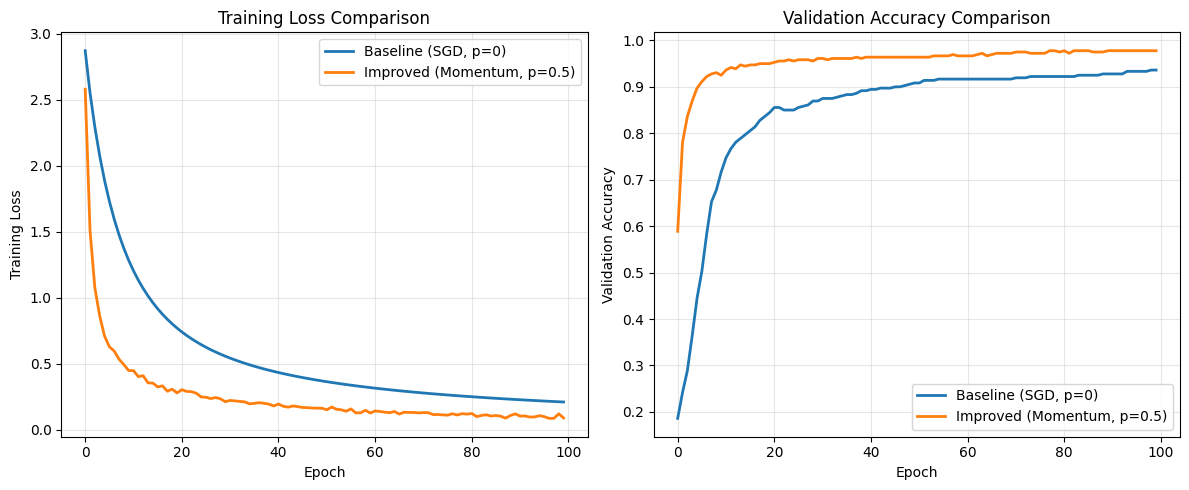

In [31]:
results = run_experiment()